# Import Needed Libraries and Files

In [1]:
import modelalt
import data
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
from tqdm import tqdm
from scipy.integrate import solve_ivp

# Load Dataset

In [2]:
train_dataset = data.InverseData(mat_file = "../Data/NEDC_lite.mat", outputs_npy = "../Data/outputs_train.npy", ks_npy = "../Data/ks_train.npy")
val_dataset = data.InverseData(mat_file = "../Data/NEDC_lite.mat", outputs_npy = "../Data/outputs_val.npy", ks_npy = "../Data/ks_val.npy")
test_dataset = data.InverseData(mat_file = "../Data/NEDC_lite.mat", outputs_npy = "../Data/outputs_test.npy", ks_npy = "../Data/ks_test.npy")

# Batch size arbitrary

train_loader = DataLoader(train_dataset, batch_size = 80, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 10, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 10, shuffle = False)

In [3]:
# Check loaded file sizes

print('Training Model Outputs Array Size:', len(train_dataset))
print('Validation Model Outputs Array Size:', len(val_dataset))
print('Test Model Outputs Array Size:', len(test_dataset))

# Calculate and display the number of mini-batches

num_train_minibatches = len(train_loader)
num_val_minibatches = len(val_loader)
num_test_minibatches = len(test_loader)

print(f"Number of Mini-Batches: {num_train_minibatches}")
print(f"Number of Mini-Batches: {num_val_minibatches}")
print(f"Number of Mini-Batches: {num_test_minibatches}")

Training Model Outputs Array Size: 800
Validation Model Outputs Array Size: 100
Test Model Outputs Array Size: 100
Number of Mini-Batches: 10
Number of Mini-Batches: 10
Number of Mini-Batches: 10


# Define Hyper/parameters

In [4]:
# Setup for a parametric study

size_kernel = [3, 5, 10, 15] # kernel size, set params_user to 0
size_batch = [16, 32, 64, 100] # batch size, set params_user to 1
reg_params = [1e-2, 1e-3, 1e-4] # regularization parameter, set params_user to 2

# Sticking to 1e-3, as varying did not show any significant impact on results

reg_param = 1e-3

params_user = 2 # choose between 0, 1, 2

N_epochs = 5 # can vary

# Define loss criteria

criterion = nn.MSELoss()

# total runtime

time_total = time.time()


# Model Instantiation

In [5]:
CNNmodel = modelalt.CNN(channels_in = 8)

# Training Loop

Epoch [1/5],
Training Data: Loss - 0.8911216855049133 Accuracy - 0.9989174604415894
Epoch [2/5],
Training Data: Loss - 0.9813717007637024 Accuracy - 1.0006023645401
Epoch [3/5],
Training Data: Loss - 1.053312063217163 Accuracy - 1.001143455505371
Epoch [4/5],
Training Data: Loss - 0.9634497165679932 Accuracy - 1.000430941581726
Epoch [5/5],
Training Data: Loss - 0.9519118070602417 Accuracy - 1.0010956525802612


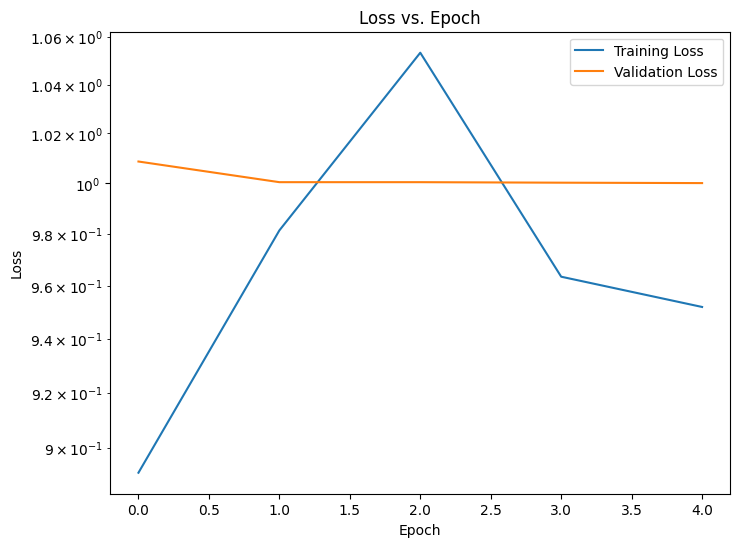

Final Losses: Training Loss - 0.9519118070602417, Validation Loss - 1.0000349462032319
Runtime: 1482.2093949317932 s


In [6]:
# Parameter study case: select which parameter to vary, omitted for this project

#if params_user == 0:
#    params = size_kernel
#elif params_user == 1:
#    params = size_batch
#elif params_user == 2:
#    params = reg_params

# Initialize for future value storage

train_loss_metrics = []
val_loss_metrics = []
# test_loss_metrics = []

train_accuracy_metrics = []
#val_accuracy_metrics = []
#test_accuracy_metrics = []

param_time = []

#for param in params:

#    if params_user == 0:
#        k = param
#        N_batch = 100
#        reg_param = 1e-3
#    elif params_user == 1:
#        N_batch = param
#        k = 3
#        reg_param = 1e-3
#    elif params_user == 2:
#        reg_param = param
#        k = 3
#        N_batch = 100

# Per epoch

train_loss_history = []
val_loss_history = []
# test_loss_history = []

train_accuracy_history = []
#val_accuracy_history = []
#test_accuracy_history = []

t_0 = time.time()

t_0_main = time.time()

# Define optimizer, Use ADAM with regularization parameter as weight decay

optimizer = optim.Adam(CNNmodel.parameters(), weight_decay = reg_param)

for epoch in range(1, N_epochs + 1):

    running_train_loss = 0.0
    running_train_acc = 0.0

    for batch in train_loader:
        x_batch = batch[0]
        y_batch = batch[1]

        # zero the gradients

        optimizer.zero_grad()

        # forward

        y_pred = CNNmodel(x_batch)

        # compute loss

        loss = criterion(y_pred[:], y_batch[:])

        # back propagation

        loss.backward()

        # update the parameters theta

        optimizer.step()

        # Relative L2 error

        with torch.no_grad():
            err = y_pred - y_batch
            error = err.cpu().detach().numpy()
            y_b = y_batch.cpu().detach().numpy()
            train_accuracy = np.linalg.norm(error) / np.linalg.norm(y_b)
        
        running_train_loss += loss.item()
        running_train_acc += train_accuracy.item()

    # Average metrics for the epoch
    
    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_acc = running_train_acc / len(train_loader)
    
    # Append to history
    
    train_accuracy_history.append(train_accuracy)
    train_loss_history.append(loss.item())

    # Validation
    
    running_val_loss = 0.0
    # running_test_loss = 0.0

    with torch.no_grad():

        CNNmodel.eval()
        for val_batch in val_loader:
            val_x_batch = val_batch[0]
            val_y_batch = val_batch[1]

            y_val_pred = CNNmodel(torch.Tensor(val_x_batch).to(torch.float32))

            val_loss = criterion(y_val_pred, torch.Tensor(val_y_batch).to(torch.float32))
            running_val_loss += val_loss.item()

        # for test_batch in test_loader:
        #     test_x_batch = test_batch[0]
        #     test_y_batch = test_batch[1]

        #     y_test_pred = CNNmodel(torch.Tensor(test_x_batch).to(torch.float32))

        #     test_loss = criterion(y_test_pred, torch.Tensor(test_y_batch).to(torch.float32))
        #     running_test_loss += test_loss.item()
            
    # Average metrics for the epoch
    
    avg_val_loss = running_val_loss / len(val_loader)
    # avg_test_loss = running_test_loss / len(test_loader)
    
    # Append to history
    
    val_loss_history.append(avg_val_loss)
    # test_loss_history.append(avg_test_loss)

    #test_acc = abs(y_test_pred.to("cpu").detach().numpy() - test_y_batch) / test_y_batch
    # test_acc[~np.isfinite(test_acc)] = 0
    #test_accuracy = np.nanmean(test_acc)
    #test_accuracy_history.append(test_accuracy)

    # Set back to training
    
    CNNmodel.train()

    # Periodically print epoch results
    
    if epoch % int(N_epochs / 5) == 0: # asumming N_epochs/20 is an integer
        print(f"Epoch [{epoch}/{int(N_epochs)}],")
        print(f"Training Data: Loss - {loss.item()} Accuracy - {train_accuracy}")

train_loss_metrics.append(np.mean(train_loss_history[-100:]))
val_loss_metrics.append(np.mean(val_loss_history[-100:]))
# test_loss_metrics.append(np.mean(test_loss_history[-100:]))

train_accuracy_metrics.append(np.mean(train_accuracy_history[-100:]))
#test_accuracy_metrics.append(np.mean(test_accuracy_history[-100:]))

# Plotting

plt.figure(figsize = (8,6))
plt.box(True)
plt.plot(train_loss_history, label = "Training Loss")
plt.plot(val_loss_history, label = "Validation Loss")
# plt.plot(test_loss_history, label = "Test Loss")
plt.gca().set_yscale('log')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Loss vs. Epoch')
plt.show()

# Store and print final loss figures

final_train_loss = train_loss_history[-1]
final_val_loss = val_loss_history[-1]
# final_test_loss = test_loss_history[-1]

print(f"Final Losses: Training Loss - {final_train_loss}, Validation Loss - {final_val_loss}")

# Print runtime

t_1_main = time.time()

print(f"Runtime: {t_1_main - t_0_main} s")
param_time.append(t_1_main - t_0_main)


# Testing Loop

Epoch [1/5],
Test Data: Loss - 0.7813742756843567 Accuracy - 0.9998119473457336
Epoch [2/5],
Test Data: Loss - 0.7813742756843567 Accuracy - 0.9998119473457336
Epoch [3/5],
Test Data: Loss - 0.7813742756843567 Accuracy - 0.9998119473457336
Epoch [4/5],
Test Data: Loss - 0.7813742756843567 Accuracy - 0.9998119473457336
Epoch [5/5],
Test Data: Loss - 0.7813742756843567 Accuracy - 0.9998119473457336


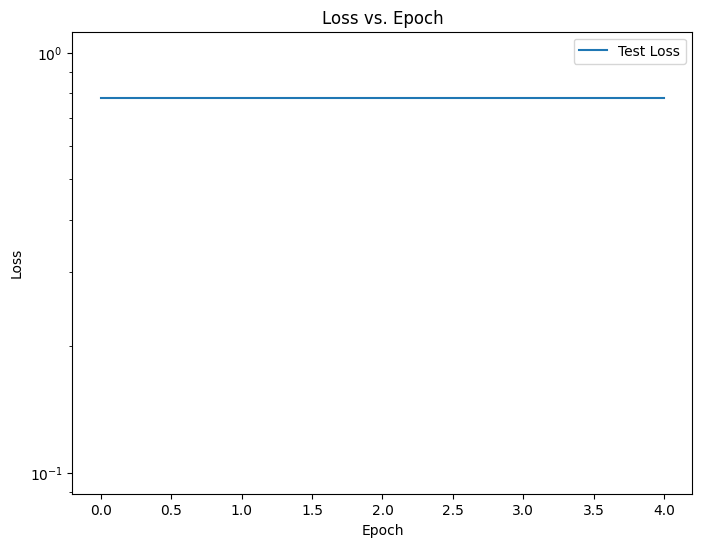

Final Test Loss: 0.7813742756843567
Runtime: 17.762839317321777 s


In [7]:
# Test loop

test_loss_metrics = []
test_accuracy_metrics = []

param_time = []

# Per epoch

test_loss_history = []
test_accuracy_history = []

t_0 = time.time()

t_0_main = time.time()

# Define optimizer, Use ADAM with regularization parameter as weight decay

optimizer = optim.Adam(CNNmodel.parameters(), weight_decay = reg_param)

for epoch in range(1, N_epochs + 1):
    with torch.no_grad():

        CNNmodel.eval()
    
        running_test_loss = 0.0
        running_test_acc = 0.0

        for batch in test_loader:
            x_test_batch = batch[0]
            y_test_batch = batch[1]

            # zero the gradients

            optimizer.zero_grad()

            # forward

            y_test_pred = CNNmodel(x_test_batch)

            # compute loss

            test_loss = criterion(y_test_pred[:], y_test_batch[:])

            # # back propagation

            # loss.backward()

            # # update the parameters theta

            # optimizer.step()

            # Relative L2 error
            
            test_err = y_test_pred - y_test_batch
            test_error = test_err.cpu().detach().numpy()
            test_y_b = y_test_batch.cpu().detach().numpy()
            test_accuracy = np.linalg.norm(test_error) / np.linalg.norm(test_y_b)
        
            running_test_loss += test_loss.item()
            running_test_acc += test_accuracy.item()

        # Average metrics for the epoch
        
        avg_test_loss = running_test_loss / len(test_loader)
        avg_test_acc = running_test_acc / len(test_loader)
        
        # Append to history
        
        test_accuracy_history.append(test_accuracy)
        test_loss_history.append(test_loss.item())

        # Periodically print epoch results
        
        if epoch % int(N_epochs / 5) == 0: # asumming N_epochs/20 is an integer
            print(f"Epoch [{epoch}/{int(N_epochs)}],")
            print(f"Test Data: Loss - {test_loss.item()} Accuracy - {test_accuracy}")

test_loss_metrics.append(np.mean(test_loss_history[-100:]))
test_accuracy_metrics.append(np.mean(test_accuracy_history[-100:]))

# Plotting

plt.figure(figsize = (8,6))
plt.box(True)
plt.plot(test_loss_history, label = "Test Loss")
plt.gca().set_yscale('log')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Loss vs. Epoch')
plt.show()

# Store and print final loss figure

final_test_loss = test_loss_history[-1]

print(f"Final Test Loss: {final_test_loss}")

# Print runtime

t_1_main = time.time()

print(f"Runtime: {t_1_main - t_0_main} s")
param_time.append(t_1_main - t_0_main)


# RMSE Determination for Predicted As

In [8]:
# Evaluation loop over test loader

# Ensure the CNN is in evaluation mode

CNNmodel.eval()

all_A_true = []
all_A_pred = []

print(f"Starting evaluation over {len(val_loader.dataset)} test samples...")

with torch.no_grad(): # No gradients needed for direct inference
    for batch in tqdm(val_loader, desc="Evaluating Test Set"):
        
        # Depending on your dataset, batch[0] is the input (sensor data) 
        # and batch[1] is the target (the true A values)

        x_batch = batch[0].float()
        y_batch = batch[1].float()
        
        # Direct forward pass to predict the A values

        y_pred = CNNmodel(x_batch)
        
        # Store results (appending the whole batch at once is much faster)

        all_A_true.append(y_batch.cpu().numpy())
        all_A_pred.append(y_pred.cpu().numpy())


# RMSE calculation

# Concatenate the lists of batches into single massive arrays
# Final Shape: [total_samples, 6]

all_A_true = np.concatenate(all_A_true, axis=0)
all_A_pred = np.concatenate(all_A_pred, axis=0)

# Calculate squared errors

squared_errors = (all_A_pred - all_A_true) ** 2

# Calculate RMSE per parameter (column-wise)

rmse_per_param = np.sqrt(np.mean(squared_errors, axis=0))

# Calculate total overall RMSE across all parameters and samples

overall_rmse = np.sqrt(np.mean(squared_errors))

# Print the results

param_names = ["A_ads", "A_des", "A_std", "A_fst", "A_slw", "A_oxi"]

print("\n" + "="*40)
print("Direct Inverse Model RMSE Results")
print("="*40)
print(f"Overall Total RMSE: {overall_rmse:.6f}\n")

for i, name in enumerate(param_names):

    # Depending on the output size of your model, make sure it matches 6

    if i < len(rmse_per_param):
      
        print(f"{name:6s} RMSE: {rmse_per_param[i]:.6f}")


Starting evaluation over 100 test samples...


Evaluating Test Set: 100%|██████████| 10/10 [00:03<00:00,  3.07it/s]


Direct Inverse Model RMSE Results
Overall Total RMSE: 1.000018

A_ads  RMSE: 1.000170
A_des  RMSE: 1.000101
A_std  RMSE: 1.000002
A_fst  RMSE: 0.999895
A_slw  RMSE: 0.999920
A_oxi  RMSE: 1.000016


Apply Trained Model to Real Experimental Measured Downstream NOx

In [10]:
# Alternative data load that keeps inputs and outputs separate

outputs_train = np.load("../Data/outputs_train.npy").astype(np.float32)
outputs_val   = np.load("../Data/outputs_val.npy").astype(np.float32)
outputs_test  = np.load("../Data/outputs_test.npy").astype(np.float32)

As_train = np.load("../Data/ks_train.npy").astype(np.float64)
As_val   = np.load("../Data/ks_val.npy").astype(np.float64)
As_test  = np.load("../Data/ks_test.npy").astype(np.float64)

print("Training Samples:", outputs_train.shape)
print("Validation Samples:  ", outputs_val.shape)
print("Test Samples: ", outputs_test.shape)

print("Training As:", As_train.shape)
print("Validation As:  ", As_val.shape)
print("Test As: ", As_test.shape)

print("Total Datasets:", len(As_train) + len(As_val) + len(As_test))


Training Samples: (800, 11993)
Validation Samples:   (100, 11993)
Test Samples:  (100, 11993)
Training As: (800, 6)
Validation As:   (100, 6)
Test As:  (100, 6)
Total Datasets: 1000


Load Base Signals From Simulink Model

In [11]:
# Load operating-condition signals from NEDC_lite.mat

mat_path = "../Data/NEDC_lite.mat"

mat = sio.loadmat(mat_path, squeeze_me = True, struct_as_record = False)

def get_signal(name):
    return np.asarray(mat[name].signals.values, dtype = np.float32).reshape(-1)

F_NOx = get_signal("F_NOx_sensor") # Upstream NOx
Dosing = get_signal("Dosing") # Urea dosing
Temp = get_signal("Temp") # Exhaust temperature
ExhaustFlow = get_signal("ExhaustFlow") # Exhaust mass flow rate
Adblue = get_signal("adblue_mg") # Adblue mass flow rate
O2 = get_signal("O2")     # O2
Temp_DOC_up = get_signal("Temp_DOC_up") # Upstream temperature

# Common signals for all simulations
# Shape: [time, 5]
base_signal_stack = np.stack(
    [F_NOx, Dosing, Temp, ExhaustFlow, Adblue, O2, Temp_DOC_up],
    axis=1
)

base_signals = np.transpose(base_signal_stack)

print("Base Signals:", base_signals.shape)


Base Signals: (7, 11993)


Downsample Option

In [12]:
# Full length is 11993, which can be cumbersom for CNN architecture.
# downsample = 10 gives around 1200 time steps.
# downsample = 1 for standard testing

downsample = 1

base_signals = base_signals[::downsample]
outputs_train = outputs_train[:, ::downsample]
outputs_val   = outputs_val[:, ::downsample]
outputs_test  = outputs_test[:, ::downsample]

print("After Downsampling:")
print("base_signals:", base_signals.shape)
print("outputs_train:", outputs_train.shape)


After Downsampling:
base_signals: (7, 11993)
outputs_train: (800, 11993)


Input Scaling

In [13]:
# Per-channel min-max scaling for common operating signals

base_sigs_min = base_signals.min(axis=1, keepdims=True)
base_sigs_max = base_signals.max(axis=1, keepdims=True)

base_sigs_scaled = (base_signals - base_sigs_min) / (base_sigs_max - base_sigs_min + 1e-8)

# Downstream NOx scaling using training set only

NOx_down_min = outputs_train.min()
NOx_down_max = outputs_train.max()

def scale_NOx_down(x):
    return (x - NOx_down_min) / (NOx_down_max - NOx_down_min + 1e-8)

outputs_train_scaled = scale_NOx_down(outputs_train)
outputs_val_scaled   = scale_NOx_down(outputs_val)
outputs_test_scaled  = scale_NOx_down(outputs_test)


Label Scaling (log10(A) and z-normalization)

In [14]:
param_names = ["A_ads", "A_des", "A_std", "A_fst", "A_slw", "A_NH3ox"]

log_A_train = np.log10(As_train)
log_A_val   = np.log10(As_val)
log_A_test  = np.log10(As_test)

A_mean = log_A_train.mean(axis=0, keepdims=True)
A_std = log_A_train.std(axis=0, keepdims=True) + 1e-8

y_train = ((log_A_train - A_mean) / A_std).astype(np.float32)
y_val   = ((log_A_val   - A_mean) / A_std).astype(np.float32)
y_test  = ((log_A_test  - A_mean) / A_std).astype(np.float32)

print("Training As:", y_train.shape)
print("Validation As:  ", y_val.shape)
print("Testing As: ", y_test.shape)

def inverse_transform_A(y_scaled):
  
  # Convert normalized network output back to physical A values.
    
    y_scaled = np.asarray(y_scaled)
    log_A = y_scaled * A_std + A_mean

    return 10 ** log_A


Training As: (800, 6)
Validation As:   (100, 6)
Testing As:  (100, 6)


Loading Dataset

In [15]:
class SCRSequenceDataset(Dataset):
    def __init__(self, outputs_scaled, labels_scaled, base_scaled):
        self.outputs_scaled = outputs_scaled.astype(np.float32)
        self.labels_scaled = labels_scaled.astype(np.float32)
        self.base_scaled = base_scaled.astype(np.float32)

    def __len__(self):
        return self.outputs_scaled.shape[0]

    def __getitem__(self, idx):
        # Downstream NOx for this simulation
        
        NOx_down = self.outputs_scaled[idx][None, :]   # [time, 1]

        # Input sequence: [F_NOx, Temp, O2, ExhaustFlow, Adblue, downstream_NOx]
        
        x = np.concatenate([self.base_scaled, NOx_down], axis=0)  # [time, 6]

        y = self.labels_scaled[idx]  # [6]

        return torch.from_numpy(x), torch.from_numpy(y)


train_ds = SCRSequenceDataset(outputs_train_scaled, y_train, base_sigs_scaled)
val_ds   = SCRSequenceDataset(outputs_val_scaled,   y_val,   base_sigs_scaled)
test_ds  = SCRSequenceDataset(outputs_test_scaled,  y_test,  base_sigs_scaled)

BATCH_SIZE = 16

train_load = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True, num_workers=0)
val_load   = DataLoader(val_ds,   batch_size = BATCH_SIZE, shuffle=False, num_workers=0)
test_load  = DataLoader(test_ds,  batch_size = BATCH_SIZE, shuffle=False, num_workers=0)

x0, y0 = train_ds[0]

print("Shape of One Input Sequence:", x0.shape)
print("Shape of One Label:", y0.shape)


Shape of One Input Sequence: torch.Size([8, 11993])
Shape of One Label: torch.Size([6])


## Real Sensor Measurement Comparison

Get Predicted As

In [16]:
# This is portion is the proof-of-concept using a real sensor trace.
# It uses R_NOx_sensor from NEDC_lite.mat as the downstream NOx input.

R_NOx_measured = get_signal("R_NOx_sensor")[::downsample]
R_NOx_measured_scaled = scale_NOx_down(R_NOx_measured)

#R_NOx_measured_scaled_input = np.transpose(R_NOx_measured_scaled)

print(R_NOx_measured_scaled.shape)

#print("R_NOx_sensor_measured shape:", R_NOx_measured.shape)
#print("R_NOx_sensor_measured_scaled shape:", R_NOx_measured_scaled.shape)

x_real = np.concatenate([base_sigs_scaled, R_NOx_measured_scaled[None, :]], axis = 0).astype(np.float32)

x_real_tensor = torch.from_numpy(x_real[None, :, :])

CNNmodel.eval()

with torch.no_grad():
    predict_real_scaled = CNNmodel(x_real_tensor).cpu().numpy()

predict_real_A = inverse_transform_A(predict_real_scaled)[0]

#print(predict_real_A)

real_result = pd.DataFrame({"parameter": param_names, "predicted pre-exponential factor A": predict_real_A})

print(f"\nPredicted Factors From Real Measured R_NOx_sensor: {real_result}")
#print(real_result)


# If your SCR simulator function expects this order:
# [k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox]
# Use this reorder:

predict_real_for_SCR_model = predict_real_A[[2, 3, 4, 0, 1, 5]]

print(f"\nReordered for SCR model [A_std, A_fst, A_slw, A_ads, A_des, A_nh3ox]: {predict_real_for_SCR_model}")
#print(predict_real_for_SCR_model)


(11993,)

Predicted Factors From Real Measured R_NOx_sensor:   parameter  predicted pre-exponential factor A
0     A_ads                        4.024165e+00
1     A_des                        4.786315e+04
2     A_std                        2.717303e+09
3     A_fst                        6.584215e+09
4     A_slw                        2.718705e+11
5   A_NH3ox                        6.455739e+05

Reordered for SCR model [A_std, A_fst, A_slw, A_ads, A_des, A_nh3ox]: [2.71730343e+09 6.58421495e+09 2.71870490e+11 4.02416496e+00
 4.78631458e+04 6.45573906e+05]


## SCR Model

In [17]:
def run_SCR_model(A_std_0, A_fst_0, A_slw_0, A_ads_0, A_des_0, A_NH3ox_0):

    #from scipy.integrate import solve_ivp

    # ---------- Lookup tables ----------
    
    NO_Ratio_BP = np.array(
        [131.3121, 161.1298, 224.8357, 265.8866, 322.246, 363.2026, 415.0273, 469.8143, 511.78],
        dtype=float,
    )

    NO_Ratio_TBL = np.array(
        [0.785714, 0.979592, 0.360825, 0.324138, 0.366906, 0.497227, 0.617626, 0.702214, 0.761749],
        dtype=float,
    )

    Density_BP = np.array(
        [260, 280, 300, 350, 400, 450, 500, 600, 800, 1000, 1200, 1400],
        dtype=float,
    )

    Density_TBL = np.array(
        [1.340, 1.245, 1.161, 0.995, 0.871, 0.774, 0.696, 0.580, 0.435, 0.348, 0.290, 0.249],
        dtype=float,
    )

    # ---------- Parameters ----------

    PARAMS = {
        "A_std_0": A_std_0,
        "A_fst_0": A_fst_0,
        "A_slw_0": A_slw_0,
        "A_ads_0": A_ads_0,
        "A_des_0": A_des_0,
        "A_NH3ox_0": A_NH3ox_0,
        "E1": 77300.0,
        "E2": 45200.0,
        "E3": 109000.0,
        "E4": -10200.0,
        "E5": 67500.0,
        "E6": 91100.0,
        "R": 8.314,
        "Volume_m3": 0.000899,
        "Ohm": 900.0,
        "switch_temp_SCR_c": 190.0,
        "switch_NO_ratio": 0.5,
    }

    def lookup(x, bp, table):
        return np.interp(x, bp, table, left = table[0], right = table[-1])

    def load_timeseries(mat_dict, name):
        obj = mat_dict[name][0, 0]
        t = np.asarray(obj["time"]).squeeze().astype(float)
        v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
        return t, v

    def deduplicate_time(t, *signals):
        _, first_idx = np.unique(t, return_index = True)
        first_idx = np.sort(first_idx)
        out = [t[first_idx]]
        
        for s in signals:
            out.append(s[first_idx])
        return tuple(out)

    def ppm_to_molm3(ppm):
        return ppm / 22.4 / 1000.0

    def molm3_to_ppm(c):
        return c * 1000.0 * 22.4

    def rate_constants(temp_c):
        T = np.asarray(temp_c, dtype=float) + 273.15
        k_std = PARAMS["A_std_0"] * np.exp(-PARAMS["E1"] / (PARAMS["R"] * T))
        k_fst = PARAMS["A_fst_0"] * np.exp(-PARAMS["E2"] / (PARAMS["R"] * T))
        k_slw = PARAMS["A_slw_0"] * np.exp(-PARAMS["E3"] / (PARAMS["R"] * T))
        k_ads = PARAMS["A_ads_0"] * np.exp(-PARAMS["E4"] / (PARAMS["R"] * T))
        k_des = PARAMS["A_des_0"] * np.exp(-PARAMS["E5"] / (PARAMS["R"] * T))
        k_NH3ox = PARAMS["A_NH3ox_0"] * np.exp(-PARAMS["E6"] / (PARAMS["R"] * T))
        return T, k_std, k_fst, k_slw, k_ads, k_des, k_NH3ox

    def gas_exchange_factor(exhaust_mfr, temp_c):
        T, *_ = rate_constants(temp_c)
        rho = lookup(T, Density_BP, Density_TBL)
        exhaust_kg_s = np.asarray(exhaust_mfr, dtype=float) * 1e-6
        q_m3_s = exhaust_kg_s / np.maximum(rho, 1e-12)
        F = q_m3_s / PARAMS["Volume_m3"]
        return T, rho, F

    def feedforward_adblue(temp_doc_up_c, NOx_f_ppm, exhaust_mfr, temp_SCR_up_c):
        NO_ratio = lookup(temp_doc_up_c, NO_Ratio_BP, NO_Ratio_TBL)

        mw_NO = 14.007 + 15.999
        mw_NO2 = 14.007 + 15.999 * 2.0
        mw_NH3 = 14.007 + 1.008 * 3.0
        mw_exh = 29.47

        c_ratio = (NO_ratio * mw_NO + (1.0 - NO_ratio) * mw_NO2) / mw_exh
        NH3_vs_NOx_ratio = mw_NH3 / (NO_ratio * mw_NO + (1.0 - NO_ratio) * mw_NO2)

        exhaust_kg_s = exhaust_mfr * 1e-6
        NOx_mass_like = c_ratio * NOx_f_ppm * exhaust_kg_s
        base_NH3 = NH3_vs_NOx_ratio * NOx_mass_like
        extra_NO2_comp = base_NH3 * (1.0 - 2.0 * NO_ratio) * 0.333

        alpha_ratio = np.where(NO_ratio >= PARAMS["switch_NO_ratio"],
            base_NH3,
            base_NH3 + extra_NO2_comp,
        )

        urea_mfr = alpha_ratio * (60.0 / 34.0)
        adblue_mfr = urea_mfr * (100.0 / 32.4)
        adblue_mfr = np.where(temp_SCR_up_c >= PARAMS["switch_temp_SCR_c"], adblue_mfr, 0.0)

        return adblue_mfr, NO_ratio

    def adblue_to_NH3_in_molm3(adblue_mfr, exhaust_mfr):
        return (
            ((adblue_mfr * (32.4 / 100.0) * (34.0 / 60.0)) / np.maximum(exhaust_mfr, 1e-12))
            * 1e6 * (28.8 / 17.0) / 1000.0/ 22.4)

    # ---------- Load .mat ----------

    mat = sio.loadmat(mat_path)

    t, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
    _, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")
    _, Dosing = load_timeseries(mat, "Dosing")
    _, Temp = load_timeseries(mat, "Temp")
    _, ExhaustFlow = load_timeseries(mat, "ExhaustFlow")
    _, adblue_mg = load_timeseries(mat, "adblue_mg")
    _, O2 = load_timeseries(mat, "O2")
    _, Temp_DOC_up = load_timeseries(mat, "Temp_DOC_up")

    # Use controller dosing exactly like in original code
    
    adblue_cmd, NO_ratio = feedforward_adblue(Temp_DOC_up, F_NOx_sensor, ExhaustFlow, Temp)
    adblue_used = adblue_cmd

    NO_in_ppm = NO_ratio * F_NOx_sensor
    NO2_in_ppm = (1.0 - NO_ratio) * F_NOx_sensor

    NO_in = ppm_to_molm3(NO_in_ppm)
    NO2_in = ppm_to_molm3(NO2_in_ppm)
    NH3_in = adblue_to_NH3_in_molm3(adblue_used, ExhaustFlow)
    O2_in = O2 * 1e-2

    t_u, Temp_u, ExhaustFlow_u, O2_u, NO_in_u, NO2_in_u, NH3_in_u, R_NOx_u = deduplicate_time(
        t, Temp, ExhaustFlow, O2_in, NO_in, NO2_in, NH3_in, R_NOx_sensor
    )

    def interp_series(tt, arr):
        return float(np.interp(tt, t_u, arr, left = arr[0], right = arr[-1]))

    def rhs(tt, y):
        c_NO, c_NO2, theta, c_NH3 = np.maximum(y, 0.0)

        temp_c = interp_series(tt, Temp_u)
        exh = interp_series(tt, ExhaustFlow_u)
        o2 = interp_series(tt, O2_u)
        NO_in_val = interp_series(tt, NO_in_u)
        NO2_in_val = interp_series(tt, NO2_in_u)
        NH3_in_val = interp_series(tt, NH3_in_u)

        _, _, F = gas_exchange_factor(exh, temp_c)
        _, k_std, k_fst, k_slw, k_ads, k_des, k_NH3ox = rate_constants(temp_c)

        Rads = k_ads * c_NH3 * (1.0 - theta) * PARAMS["Ohm"]
        Rdes = k_des * theta * PARAMS["Ohm"]
        Roxi = k_NH3ox * o2 * theta * PARAMS["Ohm"]
        Rstd = k_std * c_NO * o2 * theta * PARAMS["Ohm"]
        Rfst = k_fst * c_NO * c_NO2 * theta * PARAMS["Ohm"]
        Rslw = k_slw * c_NO2 * theta * PARAMS["Ohm"]

        dc_NO = F * NO_in_val - 4.0 * Rstd - 2.0 * Rfst - F * c_NO
        dc_NO2 = F * NO2_in_val - 2.0 * Rfst - 3.0 * Rslw - F * c_NO2
        dtheta = (Rads - Rdes - 4.0 * Roxi - 4.0 * Rstd - 4.0 * Rfst - 4.0 * Rslw) / PARAMS["Ohm"]
        dc_NH3 = F * NH3_in_val - Rads + Rdes - 4.0 * Roxi - F * c_NH3

        return np.array([dc_NO, dc_NO2, dtheta, dc_NH3], dtype = float)

    sol = solve_ivp(rhs, (float(t_u[0]), float(t_u[-1])), y0 = np.array([0.0, 0.0, 0.0, 0.0], dtype = float),
        t_eval = t_u, method="BDF", r_tol = 1e-5, a_tol = 1e-8)

    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    c_NO_u, c_NO2_u, theta_u, c_NH3_u = sol.y

    c_NO = np.interp(t, t_u, c_NO_u)
    c_NO2 = np.interp(t, t_u, c_NO2_u)
    c_NH3 = np.interp(t, t_u, c_NH3_u)

    NO_out_ppm = molm3_to_ppm(c_NO)
    NO2_out_ppm = molm3_to_ppm(c_NO2)
    NH3_out_ppm = molm3_to_ppm(c_NH3)

    Model_NOx_ppm = NO_out_ppm + NO2_out_ppm
    Model_sensor_ppm = Model_NOx_ppm + NH3_out_ppm

    return t, Model_sensor_ppm


Run SCR Model With Predicted As

In [18]:
predict_real_A = np.asarray(predict_real_A, dtype = np.float64).reshape(-1)

# Print predicted As shape, should be 6

print(f"predict_real_A Shape: {predict_real_A.shape}")
#print(predict_real_A)

# Check for incorrect predicted As shape

if predict_real_A.size != 6:
    raise ValueError(f"Expected 6 predicted constants, but got shape {predict_real_A.shape}")

A_ads, A_des, A_std, A_fst, A_slw, A_NH3ox = predict_real_A

# Run SCR model with predicted As

time_s, Model_sensor_ppm = run_SCR_model(
    A_std_0=float(A_std),
    A_fst_0=float(A_fst),
    A_slw_0=float(A_slw),
    A_ads_0=float(A_ads),
    A_des_0=float(A_des),
    A_NH3ox_0=float(A_NH3ox),
)

# Verify model ran correctly and time and ppm curve shape matches expected (11993)

print("SCR model finished.")
print("time_s shape:", np.shape(time_s))
print("Model_sensor_ppm shape:", np.shape(Model_sensor_ppm))

predict_real_A Shape: (6,)


c:\Users\victo\Documents\VSCode\InverseModelling_NOxCatalyticConverter\.venv\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `r_tol`, `a_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


SCR model finished.
time_s shape: (11993,)
Model_sensor_ppm shape: (11993,)


## Plot Results

Curve Comparison

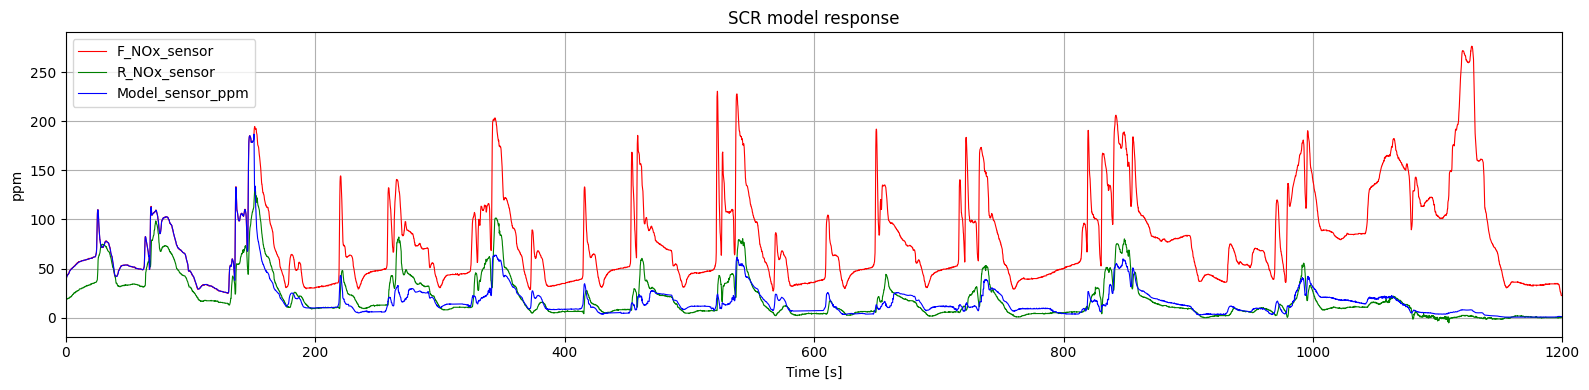

In [19]:
# Define load_timeseries function for accessibility

def load_timeseries(mat_dict, name):
    obj = mat_dict[name][0, 0]
    t = np.asarray(obj["time"]).squeeze().astype(float)
    v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
    return t, v

# ---- Load only the two measured signals for plotting ----

mat = sio.loadmat(mat_path)

# Upstream and downstream NOx readings

t_f, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
t_r, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")

# Plotting with model output using predicted As

plt.figure(figsize=(16, 4))
plt.plot(t_f, F_NOx_sensor, label = "F_NOx_sensor", color = 'red', linewidth = 0.8)
plt.plot(t_r, R_NOx_sensor, label = "R_NOx_sensor", color = 'green', linewidth = 0.8)
plt.plot(time_s, Model_sensor_ppm, label = "Model_sensor_ppm", color = 'blue', linewidth = 0.8)

plt.xlim(0, 1200)   # optional
plt.xlabel("Time [s]")
plt.ylabel("ppm")
plt.title("SCR model response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Error for Predicted As

Error Between R_NOx_sensor and Model_sensor_ppm:
L2 Error = 1.518268e+03
Relative L2 Error = 4.781070e-01
RMSE = 13.863874 ppm
MAE = 8.709120 ppm


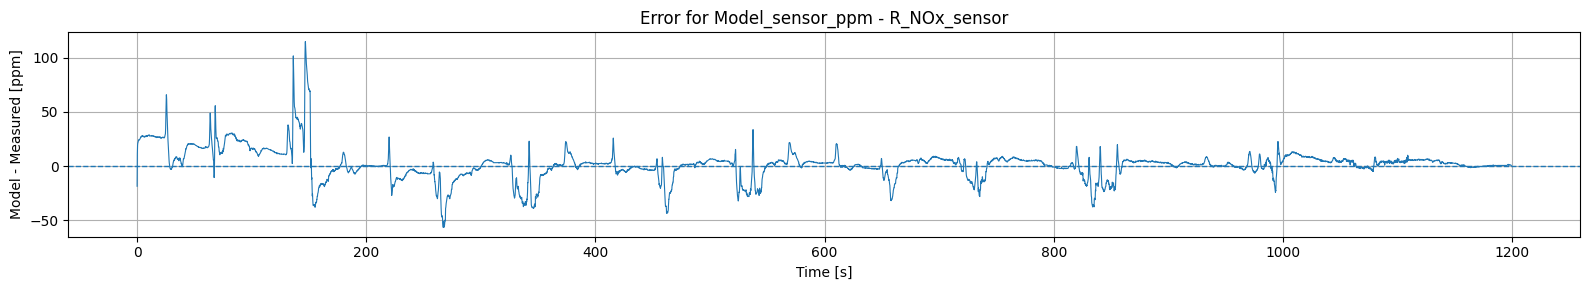

In [20]:
# Load measured downstream NOx (R_NOx_sensor)

# mat_path = "../Data/NEDC_lite.mat"

mat_real = sio.loadmat(mat_path, squeeze_me = True, struct_as_record = False)

def get_signal_from_mat(mat_dict, name):
    obj = mat_dict[name]
    t = np.asarray(obj.time, dtype = float).reshape(-1)
    v = np.asarray(obj.signals.values, dtype = float).reshape(-1)
    return t, v

t_r, R_NOx_sensor = get_signal_from_mat(mat_real, "R_NOx_sensor")

# Interpolate model output to measured R_NOx_sensor time

Model_sensor_interp = np.interp(t_r, time_s, Model_sensor_ppm)

# L2 error

model_sensor_error = Model_sensor_interp - R_NOx_sensor

L2_error = np.linalg.norm(model_sensor_error, ord=2)
relative_L2_error = L2_error / (np.linalg.norm(R_NOx_sensor, ord=2) + 1e-12)

# Other errors

MSE = np.mean(model_sensor_error ** 2)
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(model_sensor_error))

# Print error figures

print("Error Between R_NOx_sensor and Model_sensor_ppm:")
print(f"L2 Error = {L2_error:.6e}")
print(f"Relative L2 Error = {relative_L2_error:.6e}")
print(f"RMSE = {RMSE:.6f} ppm")
print(f"MAE = {MAE:.6f} ppm")

# Plotting

plt.figure(figsize = (16, 3))
plt.plot(t_r, model_sensor_error, linewidth = 0.8)
plt.axhline(0.0, linestyle = "--", linewidth = 1.0)
plt.xlabel("Time [s]")
plt.ylabel("Model - Measured [ppm]")
plt.title("Error for Model_sensor_ppm - R_NOx_sensor")
plt.grid(True)
plt.tight_layout()
plt.show()


Control Case Error

Error between R_NOx_sensor and Model_sensor_ppm
L2 error          = 9.991289e+00
Relative L2 error = 3.146285e-03
RMSE              = 14.074722 ppm
MAE               = 8.651273 ppm


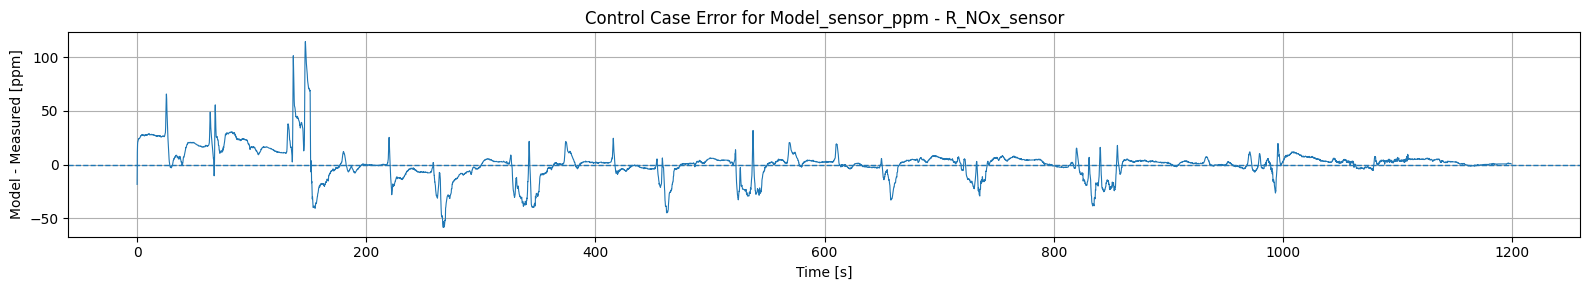

In [23]:
# Control case using As previously determined for tuned Simulink SCR model

time_s, Model_sensor_ppm = run_SCR_model(
    A_std_0 = 3.59e9,
    A_fst_0 = 8.80e9,
    A_slw_0 = 3.56e11,
    A_ads_0 = 4.32,
    A_des_0 = 4.83e4,
    A_NH3ox_0 = 6.99e5,
)

# Load measured downstream NOx (R_NOx_sensor)

# mat_path = "../Data/NEDC_lite.mat"

mat_real = sio.loadmat(mat_path, squeeze_me = True, struct_as_record = False)

def get_signal_from_mat(mat_dict, name):
    obj = mat_dict[name]
    t = np.asarray(obj.time, dtype = float).reshape(-1)
    v = np.asarray(obj.signals.values, dtype = float).reshape(-1)
    return t, v

t_r, R_NOx_sensor = get_signal_from_mat(mat_real, "R_NOx_sensor")

# Interpolate model output to measured R_NOx_sensor time

Model_sensor_interp = np.interp(t_r, time_s, Model_sensor_ppm)


# L2 error

control_error = Model_sensor_interp - R_NOx_sensor

control_L2_error = np.linalg.norm(error, ord=2)
control_relative_L2_error = control_L2_error / (np.linalg.norm(R_NOx_sensor, ord=2) + 1e-12)

control_MSE = np.mean(control_error ** 2)
control_RMSE = np.sqrt(control_MSE)
control_MAE = np.mean(np.abs(control_error))

print("Error between R_NOx_sensor and Model_sensor_ppm")
print(f"L2 error          = {control_L2_error:.6e}")
print(f"Relative L2 error = {control_relative_L2_error:.6e}")
print(f"RMSE              = {control_RMSE:.6f} ppm")
print(f"MAE               = {control_MAE:.6f} ppm")

# Plotting

plt.figure(figsize = (16, 3))
plt.plot(t_r, control_error, linewidth = 0.8)
plt.axhline(0.0, linestyle = "--", linewidth = 1.0)
plt.xlabel("Time [s]")
plt.ylabel("Model - Measured [ppm]")
plt.title("Control Case Error for Model_sensor_ppm - R_NOx_sensor")
plt.grid(True)
plt.tight_layout()
plt.show()
